# Descriptive statistics

This Google Colab notebook uses `customer_data.csv` and demonstrates various descriptive statistics.

## Getting ready

Import libraries.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

from pathlib import Path

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

print("Libraries loaded.")

Libraries loaded.


## Load the data and inspect its structure

Run the next cell and upload data file when prompted.

In [28]:

COLUMNS = ["age", "workclass", "fnlwgt", "education", "education-num",
           "marital-status",  "occupation", "relationship", "race", "sex",
           "capital-gain", "capital-loss", "hours-per-week","native-country",
           "income"]

train = pd.read_csv("../active_dataset(adult_income)/adult.data",
                    names=COLUMNS,
                    na_values="?",
                    skipinitialspace=True,
                    header=None)

test = pd.read_csv("../active_dataset(adult_income)/adult.test",
                    names=COLUMNS,
                    na_values="?",
                    skipinitialspace=True,
                    header=None,
                   skiprows=1)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (32560, 15)
Test shape: (16281, 15)


In [29]:
df = pd.concat([train, test], ignore_index=True)

In [30]:
display(df.head())
# Dataset dimensions
print(f"Dataset shape: {df.shape}")
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

# Variable names and data types
print("\nVariable information:")
df.info()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


Dataset shape: (48841, 15)
Number of observations: 48841
Number of variables: 15

Variable information:
<class 'pandas.DataFrame'>
RangeIndex: 48841 entries, 0 to 48840
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48841 non-null  int64
 1   workclass       46042 non-null  str  
 2   fnlwgt          48841 non-null  int64
 3   education       48841 non-null  str  
 4   education-num   48841 non-null  int64
 5   marital-status  48841 non-null  str  
 6   occupation      46032 non-null  str  
 7   relationship    48841 non-null  str  
 8   race            48841 non-null  str  
 9   sex             48841 non-null  str  
 10  capital-gain    48841 non-null  int64
 11  capital-loss    48841 non-null  int64
 12  hours-per-week  48841 non-null  int64
 13  native-country  47984 non-null  str  
 14  income          48841 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


#### Check for missing values

In [31]:
missing_values = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Missing percentage (%)": df.isna().mean() * 100
})

display(missing_values)

,Missing values,Missing percentage (%)
age,0,0.000000
workclass,2799,5.730841
fnlwgt,0,0.000000
education,0,0.000000
education-num,0,0.000000
marital-status,0,0.000000
occupation,2809,5.751315
relationship,0,0.000000
race,0,0.000000
sex,0,0.000000


 Since the amount of missing values is negligible, and analysis showed that the data is missing at random (MAR), the rows with missing data can be deleted

In [42]:
# Number of rows before deleting
print("Rows before:", len(df))

# Delete every row that has at least one missing value
df = df.dropna()

# Renumber the rows 0, 1, 2, ... again
df = df.reset_index(drop=True)

# Number of rows after deleting
print("Rows after:", len(df))
print("Missing values left:", df.isna().sum().sum())

Rows before: 48841
Rows after: 45221
Missing values left: 0


## Descriptive statistics

#### Descriptive statistics for numerical variables

In [43]:
numeric_columns = ["age",
                    "fnlwgt",
                    "education-num",
                    "capital-gain",
                    "capital-loss",
                    "hours-per-week",
]

# Basic descriptive statistics
numeric_statistics = df[numeric_columns].describe().T

display(numeric_statistics)

,count,mean,std,min,25%,50%,75%,max
age,45221.0,38.547931,13.218016,17.0,28.0,37.0,47.0,90.0
fnlwgt,45221.0,189737.215873,105639.045073,13492.0,117392.0,178319.0,237928.0,1490400.0
education-num,45221.0,10.118396,2.552873,1.0,9.0,10.0,13.0,16.0
capital-gain,45221.0,1101.406625,7506.511388,0.0,0.0,0.0,0.0,99999.0
capital-loss,45221.0,88.597377,404.960355,0.0,0.0,0.0,0.0,4356.0
hours-per-week,45221.0,40.938038,12.007640,1.0,40.0,40.0,45.0,99.0


#### More detailed descriptive statistics

In [44]:
descriptive_statistics = []

for column in numeric_columns:

    data = pd.to_numeric(df[column], errors="coerce").dropna()

    # Mode
    mode_values = data.mode()

    # If there is more than one mode, display all modes
    if len(mode_values) == 1:
        mode = mode_values.iloc[0]
    else:
        mode = ", ".join(
            [f"{value:.4f}" for value in mode_values]
        )

    # Quartiles
    q1 = data.quantile(0.25)
    median = data.quantile(0.50)
    q3 = data.quantile(0.75)

    # Minimum and maximum
    minimum = data.min()
    maximum = data.max()

    # Range and interquartile range
    data_range = maximum - minimum
    iqr = q3 - q1

    # Add results
    descriptive_statistics.append({
        "Variable": column,
        "Mean": data.mean(),
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Q1 (25%)": q1,
        "Q2 (50%)": median,
        "Q3 (75%)": q3,
        "Maximum": maximum,
        "Range": data_range,
        "Interquartile Range (IQR)": iqr,
        "Variance": data.var(),
        "Standard Deviation": data.std(),
        "Skewness": data.skew(),
        "Kurtosis": data.kurt()
    })

# Create the summary table
descriptive_statistics = pd.DataFrame(descriptive_statistics)

# Display the results
display(descriptive_statistics)

,Variable,Mean,Median,Mode,Minimum,Q1 (25%),Q2 (50%),Q3 (75%),Maximum,Range,Interquartile Range (IQR),Variance,Standard Deviation,Skewness,Kurtosis
0,age,38.547931,37.0,36,17,28.0,37.0,47.0,90,73,19.0,1.747160e+02,13.218016,0.532812,-0.155936
1,fnlwgt,189737.215873,178319.0,203488,13492,117392.0,178319.0,237928.0,1490400,1476908,120536.0,1.115961e+10,105639.045073,1.447510,6.184423
2,education-num,10.118396,10.0,9,1,9.0,10.0,13.0,16,15,4.0,6.517163e+00,2.552873,-0.310588,0.635181
3,capital-gain,1101.406625,0.0,0,0,0.0,0.0,0.0,99999,99999,0.0,5.634771e+07,7506.511388,11.788889,150.148193
4,capital-loss,88.597377,0.0,0,0,0.0,0.0,0.0,4356,4356,0.0,1.639929e+05,404.960355,4.516247,19.363435
5,hours-per-week,40.938038,40.0,40,1,40.0,40.0,45.0,99,98,5.0,1.441834e+02,12.007640,0.340536,3.201287


#### Frequency tables for categorical variables

In [45]:
categorical_columns = ["workclass",
                        "education",
                        "marital-status",
                        "occupation",
                        "relationship",
                        "race",
                        "sex",
                        "native-country",
                       "income"
]

for column in categorical_columns:

    print("\n" + "=" * 60)
    print(f"{column}")
    print("=" * 60)

    frequency_table = df[column].value_counts(dropna=False).to_frame(
        name="Frequency"
    )

    frequency_table["Percentage (%)"] = (
        frequency_table["Frequency"] / len(df) * 100
    )

    display(frequency_table)


workclass


,Frequency,Percentage (%)
workclass,,
Private,33307,73.653833
Self-emp-not-inc,3796,8.394330
Local-gov,3100,6.855222
State-gov,1945,4.301099
Self-emp-inc,1646,3.639902
Federal-gov,1406,3.109175
Without-pay,21,0.046439



education


,Frequency,Percentage (%)
education,,
HS-grad,14783,32.690564
Some-college,9899,21.890272
Bachelors,7569,16.737799
Masters,2514,5.559364
Assoc-voc,1959,4.332058
11th,1619,3.580195
Assoc-acdm,1507,3.332523
10th,1223,2.704496
7th-8th,823,1.819951



marital-status


...

,Frequency,Percentage (%)
sex,,
Male,30526,67.504036
Female,14695,32.495964



native-country


,Frequency,Percentage (%)
native-country,,
United-States,41291,91.309347
Mexico,903,1.996860
Philippines,283,0.625815
Germany,193,0.426793
Puerto-Rico,175,0.386988
Canada,163,0.360452
India,147,0.325070
El-Salvador,147,0.325070
Cuba,133,0.294111



income


,Frequency,Percentage (%)
income,,
<=50K,22653,50.093983
<=50K.,11360,25.121072
>50K,7508,16.602906
>50K.,3700,8.182039


#### Cross tabulations (Crosstabs)

In [46]:
crosstab_pairs = [
    ("income", "relationship"),
    ("relationship", "sex"),
    ("occupation", "native-country")
]

for row_variable, column_variable in crosstab_pairs:

    print("\n" + "=" * 70)
    print(
        f"Crosstab (frequencies): {row_variable} × {column_variable}"
    )
    print("=" * 70)

    crosstab = pd.crosstab(
        df[row_variable],
        df[column_variable]
    )

    display(crosstab)

    print("\n" + "=" * 70)
    print(
        f"Crosstab (total percentages): {row_variable} × {column_variable}"
    )
    print("=" * 70)

    crosstab_total_percent = pd.crosstab(
        df[row_variable],
        df[column_variable],
        normalize="all"
    ) * 100

    display(crosstab_total_percent.round(2))



Crosstab (frequencies): income × relationship


relationship,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Wife
income,,,,,,
<=50K,6784,6902,854,4402,2999,712
<=50K.,3375,3571,445,2119,1487,363
>50K,5679,823,35,64,213,694
>50K.,2828,405,15,41,89,322



Crosstab (total percentages): income × relationship


relationship,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Wife
income,,,,,,
<=50K,15.00,15.26,1.89,9.73,6.63,1.57
<=50K.,7.46,7.90,0.98,4.69,3.29,0.80
>50K,12.56,1.82,0.08,0.14,0.47,1.53
>50K.,6.25,0.90,0.03,0.09,0.20,0.71



Crosstab (frequencies): relationship × sex


...

sex,Female,Male
relationship,,
Husband,0.00,41.28
Not-in-family,11.97,13.91
Other-relative,1.35,1.63
Own-child,6.48,8.18
Unmarried,8.08,2.51
Wife,4.62,0.00



Crosstab (frequencies): occupation × native-country


native-country,Cambodia,Canada,China,Columbia,Cuba,Dominican-Republic,Ecuador,El-Salvador,England,France,Germany,Greece,Guatemala,Haiti,Holand-Netherlands,Honduras,Hong,Hungary,India,Iran,Ireland,Italy,Jamaica,Japan,Laos,Mexico,Nicaragua,Outlying-US(Guam-USVI-etc),Peru,Philippines,Poland,Portugal,Puerto-Rico,Scotland,South,Taiwan,Thailand,Trinadad&Tobago,United-States,Vietnam,Yugoslavia
occupation,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Adm-clerical,0,14,4,9,19,9,4,4,9,3,32,2,4,7,0,2,4,1,18,3,2,13,21,13,4,53,10,3,1,56,3,6,29,3,5,3,3,6,5139,17,1
Armed-Forces,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,0,0
Craft-repair,9,23,5,13,8,11,8,23,12,1,23,8,15,6,0,3,5,5,10,5,10,19,7,7,5,149,6,2,3,22,22,18,21,0,11,2,2,2,5503,13,3
Exec-managerial,1,20,16,6,20,4,4,2,34,9,29,18,2,0,0,1,4,4,16,12,4,8,12,23,1,26,0,4,2,18,6,3,14,4,19,13,6,1,5606,4,8
Farming-fishing,1,3,0,1,3,0,0,3,1,1,3,0,5,2,0,0,1,0,0,0,1,2,0,1,0,124,0,0,1,6,1,3,8,0,0,0,1,0,1305,2,1
Handlers-cleaners,0,2,0,5,5,7,2,11,2,0,5,1,11,3,0,2,0,0,3,0,2,7,4,2,0,108,5,3,4,15,8,6,7,0,3,0,0,0,1808,5,0
Machine-op-inspct,5,8,10,14,9,27,9,7,3,0,8,2,12,7,1,2,2,0,5,4,4,11,2,2,8,141,7,1,6,20,10,15,22,2,4,0,1,4,2561,11,3
Other-service,1,20,26,11,17,19,4,56,9,2,12,6,10,26,0,2,2,1,4,6,4,14,25,13,1,160,8,4,11,52,8,6,33,5,15,2,8,6,4183,11,5
Priv-house-serv,0,0,0,3,2,1,1,11,4,2,1,0,14,1,0,1,0,1,0,0,0,0,2,0,0,23,3,0,0,2,2,0,2,0,0,0,1,0,154,0,1



Crosstab (total percentages): occupation × native-country


native-country,Cambodia,Canada,China,Columbia,Cuba,Dominican-Republic,Ecuador,El-Salvador,England,France,Germany,Greece,Guatemala,Haiti,Holand-Netherlands,Honduras,Hong,Hungary,India,Iran,Ireland,Italy,Jamaica,Japan,Laos,Mexico,Nicaragua,Outlying-US(Guam-USVI-etc),Peru,Philippines,Poland,Portugal,Puerto-Rico,Scotland,South,Taiwan,Thailand,Trinadad&Tobago,United-States,Vietnam,Yugoslavia
occupation,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Adm-clerical,0.00,0.03,0.01,0.02,0.04,0.02,0.01,0.01,0.02,0.01,0.07,0.00,0.01,0.02,0.0,0.00,0.01,0.00,0.04,0.01,0.00,0.03,0.05,0.03,0.01,0.12,0.02,0.01,0.00,0.12,0.01,0.01,0.06,0.01,0.01,0.01,0.01,0.01,11.36,0.04,0.00
Armed-Forces,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.00,0.00
Craft-repair,0.02,0.05,0.01,0.03,0.02,0.02,0.02,0.05,0.03,0.00,0.05,0.02,0.03,0.01,0.0,0.01,0.01,0.01,0.02,0.01,0.02,0.04,0.02,0.02,0.01,0.33,0.01,0.00,0.01,0.05,0.05,0.04,0.05,0.00,0.02,0.00,0.00,0.00,12.17,0.03,0.01
Exec-managerial,0.00,0.04,0.04,0.01,0.04,0.01,0.01,0.00,0.08,0.02,0.06,0.04,0.00,0.00,0.0,0.00,0.01,0.01,0.04,0.03,0.01,0.02,0.03,0.05,0.00,0.06,0.00,0.01,0.00,0.04,0.01,0.01,0.03,0.01,0.04,0.03,0.01,0.00,12.40,0.01,0.02
Farming-fishing,0.00,0.01,0.00,0.00,0.01,0.00,0.00,0.01,0.00,0.00,0.01,0.00,0.01,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.27,0.00,0.00,0.00,0.01,0.00,0.01,0.02,0.00,0.00,0.00,0.00,0.00,2.89,0.00,0.00
Handlers-cleaners,0.00,0.00,0.00,0.01,0.01,0.02,0.00,0.02,0.00,0.00,0.01,0.00,0.02,0.01,0.0,0.00,0.00,0.00,0.01,0.00,0.00,0.02,0.01,0.00,0.00,0.24,0.01,0.01,0.01,0.03,0.02,0.01,0.02,0.00,0.01,0.00,0.00,0.00,4.00,0.01,0.00
Machine-op-inspct,0.01,0.02,0.02,0.03,0.02,0.06,0.02,0.02,0.01,0.00,0.02,0.00,0.03,0.02,0.0,0.00,0.00,0.00,0.01,0.01,0.01,0.02,0.00,0.00,0.02,0.31,0.02,0.00,0.01,0.04,0.02,0.03,0.05,0.00,0.01,0.00,0.00,0.01,5.66,0.02,0.01
Other-service,0.00,0.04,0.06,0.02,0.04,0.04,0.01,0.12,0.02,0.00,0.03,0.01,0.02,0.06,0.0,0.00,0.00,0.00,0.01,0.01,0.01,0.03,0.06,0.03,0.00,0.35,0.02,0.01,0.02,0.11,0.02,0.01,0.07,0.01,0.03,0.00,0.02,0.01,9.25,0.02,0.01
Priv-house-serv,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.02,0.01,0.00,0.00,0.00,0.03,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.34,0.00,0.00


#### z-scores

In [47]:
# Calculate z-scores for all numerical variables

z_scores = pd.DataFrame(
    stats.zscore(
        df[numeric_columns],
        nan_policy="omit"
    ),
    columns=numeric_columns,
    index=df.index
)

print("z-scores for the numerical variables:")
display(z_scores.head())


# z-scores summary

z_score_summary = pd.DataFrame({
    "Variable": numeric_columns,
    "Mean of z-scores": [
        z_scores[column].mean()
        for column in numeric_columns
    ],
    "Std of z-scores": [
        z_scores[column].std()
        for column in numeric_columns
    ],
    "Minimum z-score": [
        z_scores[column].min()
        for column in numeric_columns
    ],
    "Maximum z-score": [
        z_scores[column].max()
        for column in numeric_columns
    ]
})

display(z_score_summary.round(4))

z-scores for the numerical variables:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,0.866408,-1.007463,1.128781,-0.146728,-0.218783,-2.326714
1,-0.041454,0.245260,-0.438098,-0.146728,-0.218783,-0.078121
2,1.093373,0.425830,-1.221538,-0.146728,-0.218783,-0.078121
3,-0.798005,1.407372,1.128781,-0.146728,-0.218783,-0.078121
4,-0.117109,0.897829,1.520501,-0.146728,-0.218783,-0.078121


,Variable,Mean of z-scores,Std of z-scores,Minimum z-score,Maximum z-score
0,age,-0.0,1.0,-1.6302,3.8926
1,fnlwgt,0.0,1.0,-1.6684,12.3125
2,education-num,-0.0,1.0,-3.5719,2.3039
3,capital-gain,0.0,1.0,-0.1467,13.1751
4,capital-loss,0.0,1.0,-0.2188,10.5379
5,hours-per-week,-0.0,1.0,-3.3261,4.8355


#### Detecting outliers using z-scores

In [48]:
Z_THRESHOLD = 3

z_outlier_flags = pd.DataFrame(
    False,
    index=df.index,
    columns=numeric_columns
)

for column in numeric_columns:
    z_outlier_flags[column] = z_scores[column].abs() > Z_THRESHOLD

# Number of potential outliers for each variable
z_outlier_summary = pd.DataFrame({
    "Variable": numeric_columns,
    "Potential outliers": [
        z_outlier_flags[column].sum()
        for column in numeric_columns
    ]
})

z_outlier_summary["Percentage (%)"] = (
    z_outlier_summary["Potential outliers"]
    / len(df) * 100
)

display(z_outlier_summary.round(2))


# z-score outlier observations

for column in numeric_columns:

    outlier_indices = z_outlier_flags.index[
        z_outlier_flags[column]
    ]

    if len(outlier_indices) > 0:

        print("\n" + "=" * 70)
        print(f"z-score outliers: {column}")
        print("=" * 70)

        outlier_table = df.loc[
            outlier_indices,
            ["income", column]
        ].copy()

        outlier_table["z-score"] = z_scores.loc[
            outlier_indices,
            column
        ]

        display(
            outlier_table.sort_values(
                "z-score"
            )
        )

    else:

        print(
            f"\n{column}: No observations with |z| > {Z_THRESHOLD}."
        )

,Variable,Potential outliers,Percentage (%)
0,age,163,0.36
1,fnlwgt,471,1.04
2,education-num,294,0.65
3,capital-gain,310,0.69
4,capital-loss,2077,4.59
5,hours-per-week,626,1.38



z-score outliers: age


,income,age,z-score
67,<=50K,79,3.060408
4322,<=50K,79,3.060408
5508,<=50K,79,3.060408
5674,>50K,79,3.060408
7537,<=50K,79,3.060408
...,...,...,...
38466,<=50K.,90,3.892614
37949,<=50K.,90,3.892614
44126,>50K.,90,3.892614
43082,<=50K.,90,3.892614



z-score outliers: fnlwgt


,income,fnlwgt,z-score
26483,<=50K,506830,3.001696
41553,<=50K.,506830,3.001696
6121,>50K,506858,3.001961
41960,<=50K.,507492,3.007963
36,<=50K,507875,3.011588
...,...,...,...
14423,<=50K,1268339,10.210370
15502,<=50K,1366120,11.135994
16815,<=50K,1455435,11.981477
13379,<=50K,1484705,12.258556


...

,income,capital-gain,z-score
38668,>50K.,25124,3.200269
20812,>50K,25124,3.200269
44505,>50K.,25124,3.200269
17470,>50K,25124,3.200269
6069,>50K,25236,3.215190
...,...,...,...
3523,>50K,99999,13.175053
44986,>50K.,99999,13.175053
45016,>50K.,99999,13.175053
1255,>50K,99999,13.175053



z-score outliers: capital-loss


,income,capital-loss,z-score
187,<=50K,1340,3.090220
1395,<=50K,1340,3.090220
36374,<=50K.,1340,3.090220
38581,<=50K.,1340,3.090220
19334,<=50K,1340,3.090220
...,...,...,...
38759,<=50K.,3770,9.090873
11001,<=50K,3770,9.090873
18919,<=50K,3900,9.411896
22056,<=50K,3900,9.411896



z-score outliers: hours-per-week


,income,hours-per-week,z-score
23239,<=50K,1,-3.326089
40493,>50K.,1,-3.326089
22507,<=50K,1,-3.326089
39809,<=50K.,1,-3.326089
21276,<=50K,1,-3.326089
...,...,...,...
24078,<=50K,99,4.835472
24325,<=50K,99,4.835472
24642,>50K,99,4.835472
24681,<=50K,99,4.835472


#### Detecting outliers using the IQR method

In [49]:
iqr_outlier_flags = pd.DataFrame(
    False,
    index=df.index,
    columns=numeric_columns
)

iqr_summary = []

for column in numeric_columns:

    data = pd.to_numeric(
        df[column],
        errors="coerce"
    )

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    flags = (
        (data < lower_bound) |
        (data > upper_bound)
    )

    iqr_outlier_flags[column] = flags

    iqr_summary.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower_bound,
        "Upper bound": upper_bound,
        "Potential outliers": flags.sum(),
        "Percentage (%)": flags.mean() * 100
    })

iqr_summary = pd.DataFrame(iqr_summary)

display(iqr_summary.round(4))


# IQR outlier observations

for column in numeric_columns:

    outlier_indices = iqr_outlier_flags.index[
        iqr_outlier_flags[column]
    ]

    if len(outlier_indices) > 0:

        print("\n" + "=" * 70)
        print(f"IQR outliers: {column}")
        print("=" * 70)

        outlier_table = df.loc[
            outlier_indices,
            ["income", column]
        ].copy()

        display(
            outlier_table.sort_values(
                by=column
            )
        )

    else:

        print(
            f"\n{column}: No IQR outliers detected."
        )

,Variable,Q1,Q3,IQR,Lower bound,Upper bound,Potential outliers,Percentage (%)
0,age,28.0,47.0,19.0,-0.5,75.5,269,0.5949
1,fnlwgt,117392.0,237928.0,120536.0,-63412.0,418732.0,1331,2.9433
2,education-num,9.0,13.0,4.0,3.0,19.0,294,0.6501
3,capital-gain,0.0,0.0,0.0,0.0,0.0,3789,8.3789
4,capital-loss,0.0,0.0,0.0,0.0,0.0,2140,4.7323
5,hours-per-week,40.0,45.0,5.0,32.5,52.5,11899,26.3130



IQR outliers: age


,income,age
91,>50K,76
4356,<=50K,76
3847,<=50K,76
300,<=50K,76
4588,<=50K,76
...,...,...
4952,>50K,90
37949,<=50K.,90
205,<=50K,90
44126,>50K.,90



IQR outliers: fnlwgt


,income,fnlwgt
32710,<=50K.,418901
20452,<=50K,418961
13265,<=50K,419053
25603,<=50K,419134
25476,<=50K,419146
...,...,...
14423,<=50K,1268339
15502,<=50K,1366120
16815,<=50K,1455435
13379,<=50K,1484705


...

,income,capital-gain
21142,<=50K,114
38680,<=50K.,114
5767,<=50K,114
30550,<=50K.,114
4318,<=50K,114
...,...,...
1144,>50K,99999
14153,>50K,99999
34583,>50K.,99999
34981,>50K.,99999



IQR outliers: capital-loss


,income,capital-loss
18781,<=50K,155
3366,<=50K,213
10426,<=50K,213
16007,<=50K,213
38833,<=50K.,213
...,...,...
41987,<=50K.,3770
38759,<=50K.,3770
18919,<=50K,3900
22056,<=50K,3900



IQR outliers: hours-per-week


,income,hours-per-week
174,>50K,1
19371,<=50K,1
10582,<=50K,1
22507,<=50K,1
38555,<=50K.,1
...,...,...
25729,<=50K,99
38188,<=50K.,99
40116,<=50K.,99
20675,<=50K,99


#### Compare the two outlier-detection methods

In [50]:
outlier_comparison = pd.DataFrame({
    "Variable": numeric_columns,
    "z-score outliers": [
        z_outlier_flags[column].sum()
        for column in numeric_columns
    ],
    "IQR outliers": [
        iqr_outlier_flags[column].sum()
        for column in numeric_columns
    ]
})

outlier_comparison["Difference"] = (
    outlier_comparison["z-score outliers"]
    - outlier_comparison["IQR outliers"]
)

display(outlier_comparison)

,Variable,z-score outliers,IQR outliers,Difference
0,age,163,269,-106
1,fnlwgt,471,1331,-860
2,education-num,294,294,0
3,capital-gain,310,3789,-3479
4,capital-loss,2077,2140,-63
5,hours-per-week,626,11899,-11273


#### Box-and-whisker diagram (boxplot)

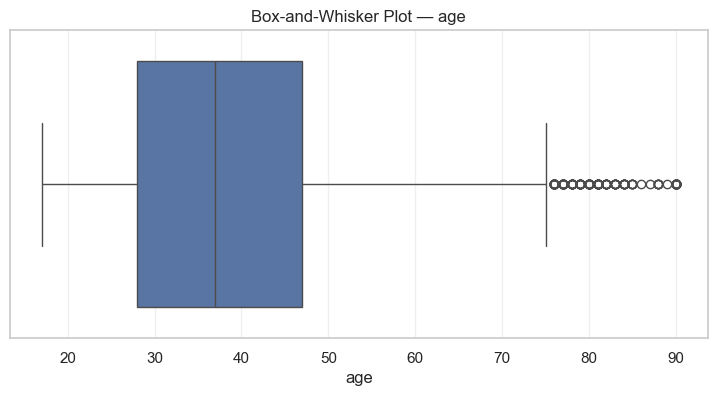

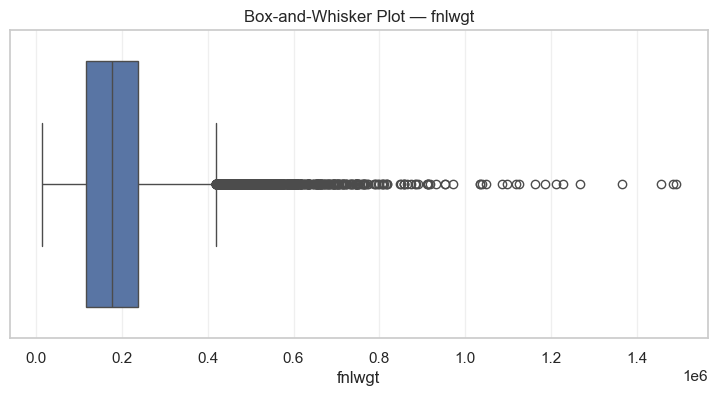

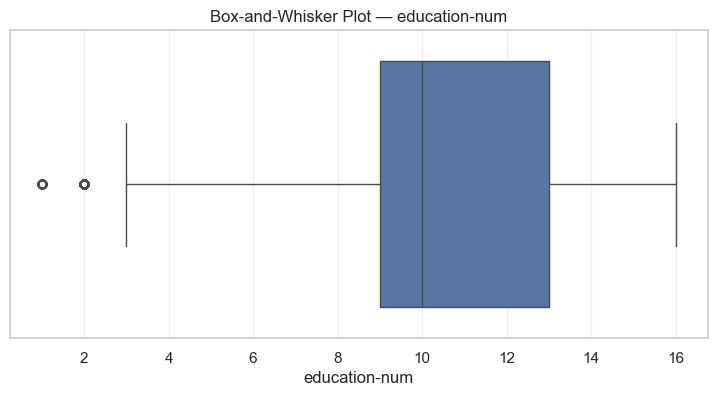

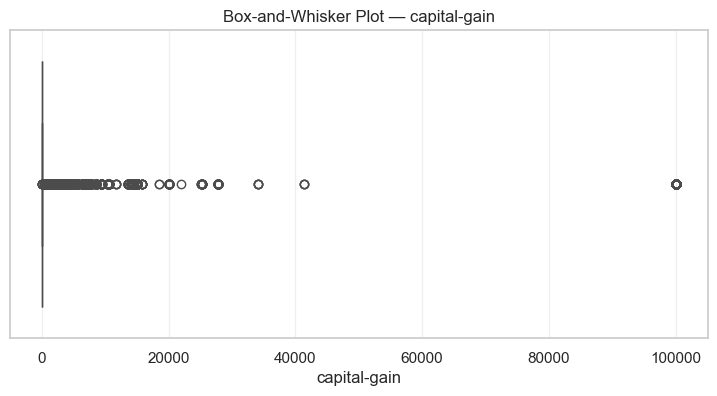

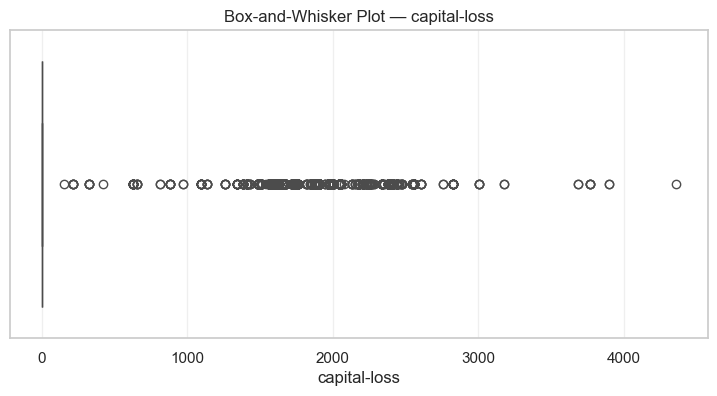

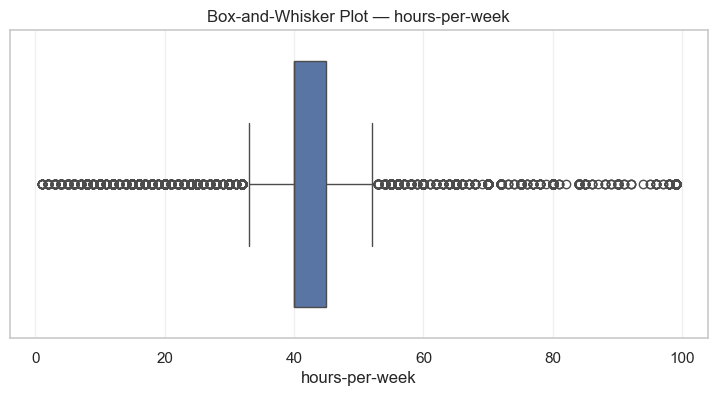

In [51]:
for column in numeric_columns:

    plt.figure(figsize=(9, 4))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(
        f"Box-and-Whisker Plot — {column}"
    )

    plt.xlabel(column)
    plt.grid(
        True,
        axis="x",
        alpha=0.3
    )

    plt.show()

#### Correlation coefficient (r)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.0000,-0.0758,0.0376,0.0797,0.0594,0.1020
fnlwgt,-0.0758,1.0000,-0.0420,-0.0041,-0.0044,-0.0187
education-num,0.0376,-0.0420,1.0000,0.1269,0.0817,0.1462
capital-gain,0.0797,-0.0041,0.1269,1.0000,-0.0321,0.0839
capital-loss,0.0594,-0.0044,0.0817,-0.0321,1.0000,0.0542
hours-per-week,0.1020,-0.0187,0.1462,0.0839,0.0542,1.0000


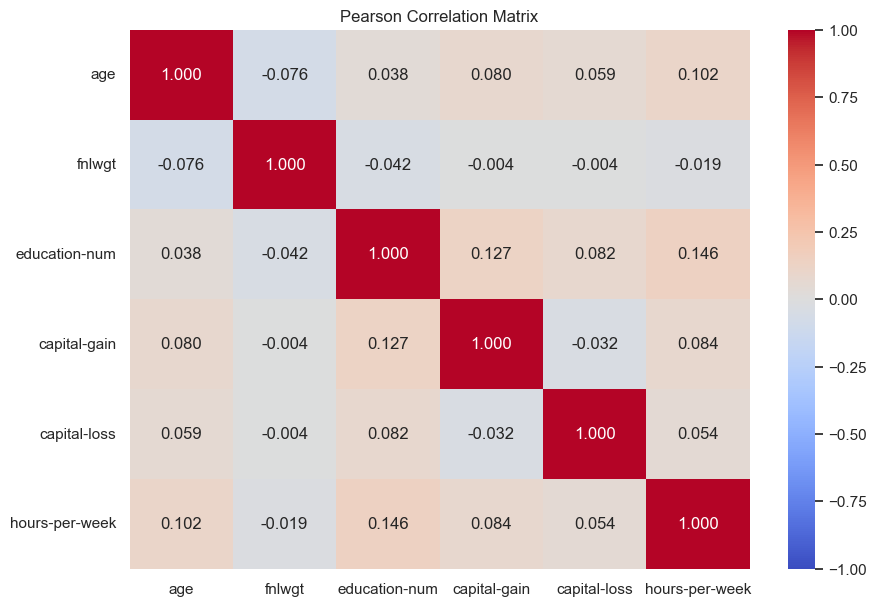

In [52]:
# Correlation matrix
correlation_matrix = df[numeric_columns].corr(method="pearson")

display(correlation_matrix.round(4))

# Correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Pearson Correlation Matrix")
plt.show()